<a href="https://colab.research.google.com/github/FOFM030711/SIMULACION-II/blob/main/PROYECT_SIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:green;">**Proyecto: Ajuste de parámetros del modelo SIR**</span>
<span style="color:orange;"></span>



1. Graficar datos.
2. Programar la solución númerica del modelo SIR.
3. Plantear un ajuste por mínimos cuadrados, $χ^2$, $(a,b)$ (chi cuadrada)
4. Usar el método MCMC (Metropolis Hastings) para optimizar $χ^2$.
5. Replantear con $pyMC$ en el enfoque bayesiano.

**Modelo SIR**


El modelo **SIR** consiste en tres Ecuacuiones Diferenciales Ordinarias No Lineales, no tiene una solucion analiticamente explicita. Es basicamente un modelo de enfermedades infecciosas.
Consiste en:
$$\frac{dS}{dt}=-aSI$$
$$\frac{dI}{dt}=aSI-bI$$
$$\frac{dR}{dt}=bI$$
donde
* $S=S(t)$ es susceptible
* $I(t)$ es infectado
* $R(t)$ es recuperado
* $a$ es la tasa de transmisión
* $b$ es la tasa de recuperación promedio

En cualquier momento, la población total es  $N = S + I + R$ y permanece constante como $N = S+ I+ R = 0$, donde el punto superior
indica la derivada con respecto al tiempo $t$.

Inicialmente, $S(t)$ es aproximadamente igual a $N$ e $I(t)$ es muy pequeño. En un brote, típicamente $I(t)$ aumenta cada día hasta alcanzar un máximo y luego tiende a disminuir lentamente.
Resulta particularmente útil determinar el número reproductivo, definido como $R_0 = \frac{a}{b}$ ya que el análisis del sistema dinámico indica que:
$$\frac{I_{max}}{N}=1-\frac{1}{R_0}(1+logR_0)$$

Por tanto, determinar los parámetros del modelo permite establecer el número máximo de infectados, una cifra que puede resultar útil para desarrollar medidas de salud pública. Incluso una vez ocurrido el evento, conocer los parámetros *a* y *b* del modelo es de interés, ya que sirven para caracterizar la enfermedad. Este es precisamente el problema que nos interesa resolver: determinar el par de parámetros $(a, b)$ del modelo $SIR$ a partir de un conjunto de datos.


**PROBLEMA:**
Marinov, plantea este problema para un conjunto de datos a un brote de gripe en un internado. Estos datos se citaron por primera vez en  y se reproducen en la tabla siguiente; la solución obtenida por Murray. Según, los valores de los parámetros $a$ y $b$ son los siguientes: $a ≈ 0.00218$ y $b ≈ 0.4485$.




**Tabla de datos de Influenza en una escuela**

$
\boxed{
\begin{array}{lc}
\text{t} & 0 &  1& 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 &  12 & 13 & 14   \\
\hline
\text{$I(t)$} & 1& 3& 6& 25& 73& 222&294 &258 &237 &191 & 125 &69 & 27 & 11& 4\\
\end{array}
}
$

**Procedemos a graficar los datos**

Importamos librerias

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


**Datos de Murray**

In [2]:

# Tiempo (días)
t_datos = np.array([
    0, 1, 2, 3, 4, 5, 6, 7,
    8, 9, 10, 11, 12, 13, 14
])

# Número de personas infectadas observado
I_datos = np.array([
    1, 3, 6, 25, 73, 222, 294, 258,
    237, 191, 125, 69, 27, 11, 4
])



*PARÁMETROS DEL MODELO*

In [3]:
# Parámetro de transmisión
a = 0.00218

# Parámetro de recuperación/remoción
b = 0.4485


 <span style="color:teal;">**1.-Grafica de los datos**</span>



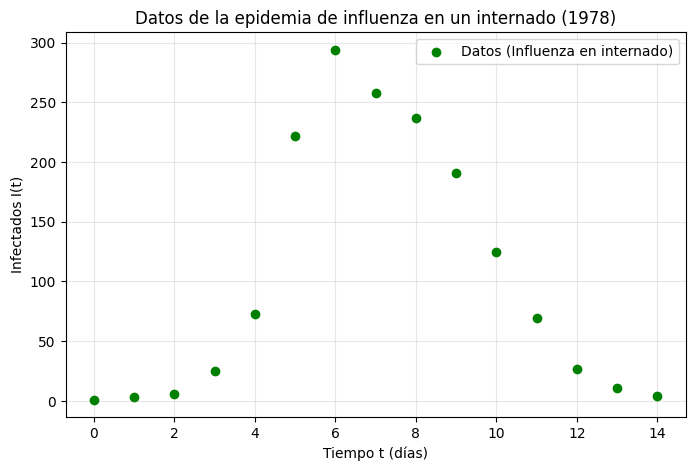

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(t_datos, I_datos, color='green',
            label='Datos (Influenza en internado)', zorder=5)
plt.xlabel('Tiempo t (días)')
plt.ylabel('Infectados I(t)')
plt.title('Datos de la epidemia de influenza en un internado (1978)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Población total
N = 763

# Susceptibles inicialmente
S0 = 762

# Infectados inicialmente
I0 = 1

# Recuperados inicialmente
R0 = 0

# Vector de condiciones iniciales
condiciones_iniciales = [S0, I0, R0]

**2. Programar la solución númerica del modelo SIR.**


**Definimos el modelo SIR**
$$\frac{dS}{dt}=-aSI$$
$$\frac{dI}{dt}=aSI-bI$$
$$\frac{dR}{dt}=bI$$
donde
* $S=S(t)$ es susceptible
* $I(t)$ es infectado
* $R(t)$ es recuperado
* $a$ es la tasa de transmisión
* $b$ es la tasa de recuperación promedio

In [6]:
def modelo_SIR(t, y):

    # Extraemos las variables
    S, I, R = y

    # Ecuación de susceptibles
    dSdt = -a * S * I

    # Ecuación de infectados
    dIdt = a * S * I - b * I

    # Ecuación de recuperados
    dRdt = b * I

    # Regresamos las derivadas
    return [dSdt, dIdt, dRdt]


In [7]:
# Intervalo de tiempo
t_inicio = 0
t_final = 14

# Creamos muchos puntos para obtener una curva suave
t = np.linspace(t_inicio, t_final, 1000)

# Resolvemos numéricamente el sistema
solucion = solve_ivp(
    modelo_SIR,
    [t_inicio, t_final],
    condiciones_iniciales,
    t_eval=t
)


Extraemos las soluciones

In [8]:
S = solucion.y[0]
I = solucion.y[1]
R = solucion.y[2]



 Graficamos la solución de Murray

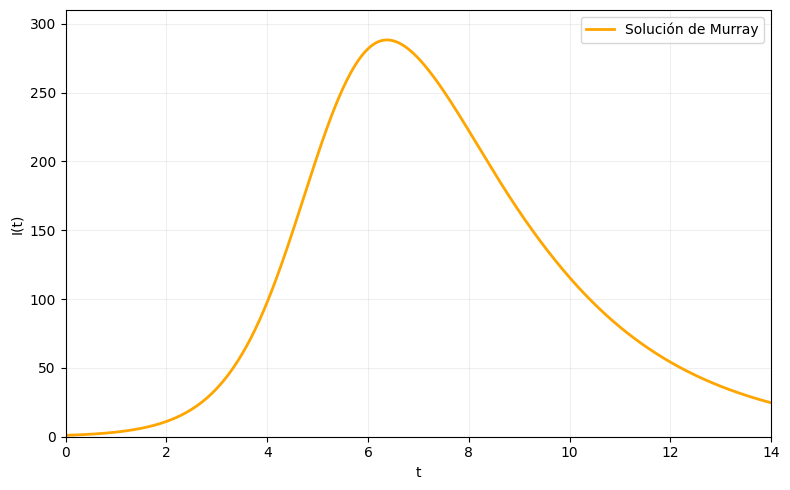

In [9]:

plt.figure(figsize=(8, 5))



# Curva de Murray
plt.plot(
    t,
    I,
    color='orange',
    linewidth=2,
    label="Solución de Murray"
)

plt.xlabel('t')
plt.ylabel('I(t)')

plt.xlim(0, 14)
plt.ylim(0, 310)

plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Esta gráfica muestra la evolución de la población infectada $I(t)$ a lo largo del tiempo $t$ según el modelo $SIR$ con los parámetros de Murray. Podemos observar una curva típica de una epidemia: el número de infectados comienza bajo, aumenta rápidamente hasta alcanzar un pico, y luego disminuye gradualmente. El pico de infectados se encuentra alrededor del día $6$, con un valor de aproximadamente $290-300$ individuos, y la curva abarca un periodo de $0$ a $14$ días.



Finalmente procedemos a gráficar los datos y la solución de Murray

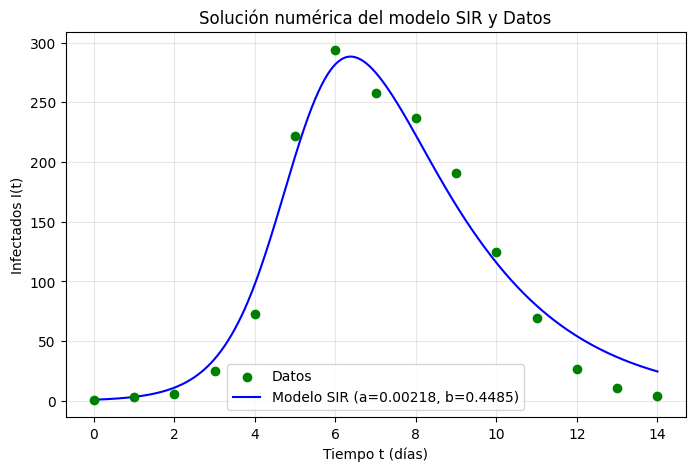

In [10]:
plt.figure(figsize=(8, 5))
# Puntos de los datos
plt.scatter(t_datos, I_datos, color='green', label='Datos', zorder=5)
# Curva de Murray
plt.plot(t, I, 'b-', label=f'Modelo SIR (a={a}, b={b})')
plt.xlabel('Tiempo t (días)')
plt.ylabel('Infectados I(t)')
plt.title('Solución numérica del modelo SIR y Datos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Esta gráfica, generada por la función_objetivo, muestra la aproximación del modelo SIR obtenida por el algoritmo genético (línea azul) en comparación con los datos reales de la epidemia (puntos verdes). Podemos observar qué tan bien el modelo ajustado por el algoritmo genético se alinea con los datos observados de la influenza en el internado. Cuanto más cerca esté la línea azul de los puntos verdes, mejor es el ajuste de los parámetros $a$ y $b$ encontrados por el algoritmo genético a los datos. Parece que el ajuste es bastante bueno, capturando la tendencia general de los infectados.




 **La solución numérica obtenida a partir de los parámetros determinados por Murray**


Utilizamos este conjunto de datos como prueba preliminar del método. Más adelante, intentaremos aplicarlo con más datos y/o condiciones más complejas. Como puede observarse, los datos nos proporcionan las condiciones iniciales, $I(0) = 1$; por tanto, al determinar los parámetros del sistema de ecuaciones, el modelo quedará completamente definido.

3. <span style="color:purple;">**Planteamos un ajuste por mínimos cuadrados, $χ^2$, $(a,b)$ (chi cuadrada)**</span>




El método de mínimos cuadrados, o más específicamente, el chi-cuadrado ($χ^2$), es una técnica común para evaluar la bondad del ajuste de un modelo a un conjunto de datos observados. Para el modelo SIR, queremos encontrar los parámetros `a` y `b` que minimicen la diferencia entre las predicciones del modelo $I_{modelo}(t)$ y los datos observados $I_{datos}(t)$.

La función $\chi^2$ se define generalmente como:

$$\chi^2(a, b) = \sum_{i=1}^{n} \frac{(I_{modelo}(t_i; a, b) - I_{datos}(t_i))^2}{\sigma_i^2}$$

Donde:
*   $I_{modelo}(t_i; a, b)$ es el número de infectados predicho por el modelo SIR en el tiempo $t_i$ con los parámetros $a$ y $b$.
*   $I_{datos}(t_i)$ es el número de infectados observado en el tiempo $t_i$.
*   $\sigma_i^2$ es la varianza asociada a cada punto de dato. Si no se conoce la varianza, a menudo se usa $I_{datos}(t_i)$ como una aproximación (especialmente para conteos de eventos como en este caso), lo que da:

$$\chi^2(a, b) = \sum_{i=1}^{n} \frac{(I_{modelo}(t_i; a, b) - I_{datos}(t_i))^2}{I_{datos}(t_i)}$$

Nuestro objetivo será minimizar esta función $\chi^2$ para encontrar los mejores valores de $a$ y $b$ que ajusten el modelo a los datos.

**Procedeos a calular chi-cuadrada  entre los datos y la solución del modelo SIR**

Definimos la función de derivadas

In [45]:
   from scipy.integrate import odeint

def chi_squared_sir(params):
    a_val, b_val = params

    # Condiciones iniciales y tiempo
    N = 763  # Población total
    I0, R0 = 1, 0
    S0 = N - I0 - R0
    condiciones_iniciales_sir = [S0, I0, R0]

    # Usamos t_datos para que la evaluación sea en los mismos puntos que los datos
    t_eval = t_datos

    # Definimos la función de derivadas
    def deriv_chi(y, t, N, a_param, b_param):
        S, I, R = y
        dSdt = -a_param * S * I
        dIdt = a_param * S * I - b_param * I
        dRdt = b_param * I
        return dSdt, dIdt, dRdt

    # Resolvemos el sistema SIR con odeint
    solucion_sir = odeint(deriv_chi, condiciones_iniciales_sir, t_eval, args=(N, a_val, b_val))
# Extraemos los valores de I(t) del modelo
    I_modelo = solucion_sir.T[1]

    chi_cuadrado = np.sum((I_modelo - I_datos)**2 / (I_datos + 1e-6))

    return chi_cuadrado

### Probando la función $\chi^2$ con los parámetros de Murray

In [46]:
# Parámetros de Murray previamente definidos en la notebook
# a = 0.00218
# b = 0.4485

chi2_murray = chi_squared_sir([a, b])
print(f"El valor de \u03C7^2 para los parámetros de Murray (a={a}, b={b}) es: {chi2_murray:.4f}")

El valor de χ^2 para los parámetros de Murray (a=0.00218, b=0.4485) es: 222.6353


### Minimización de $\chi^2$ para encontrar los parámetros óptimos

In [47]:
from scipy.optimize import minimize

# Establecemos una conjetura inicial para a y b.
# Podemos usar los valores de Murray o un punto medio razonable.
initial_guess = [0.00218, 0.4485] # [a, b]

# Definimos los límites para los parámetros a y b para que sean físicamente realistas (positivos)
# El parámetro 'a' debe ser pequeño, 'b' puede ser un poco más grande
bounds = [(1e-6, 0.1), (1e-6, 1.0)] # (min_a, max_a), (min_b, max_b)

# Realizamos la minimización
result = minimize(
    chi_squared_sir,
    initial_guess,
    method='L-BFGS-B', # Un método adecuado para problemas con límites
    bounds=bounds
)

# Extraemos los parámetros óptimos
a_opt, b_opt = result.x
chi2_opt = result.fun

print(f"Parámetros óptimos encontrados:")
print(f"  a_opt = {a_opt:.6f}")
print(f"  b_opt = {b_opt:.6f}")
print(f"Valor mínimo de \u03C7^2 = {chi2_opt:.4f}")

Parámetros óptimos encontrados:
  a_opt = 0.002277
  b_opt = 0.531540
Valor mínimo de χ^2 = 121.4984


In [48]:
chi2_murray = chi_squared_sir([a, b])
print(f"χ² con parámetros de Murray: {chi2_murray:.2f}")

χ² con parámetros de Murray: 222.64


In [49]:
a_ga = 0.00205
b_ga = 0.43552
chi2_ga = chi_squared_sir([a_ga, b_ga])
print(f"χ² con parámetros del GA: {chi2_ga:.2f}")

χ² con parámetros del GA: 430.10


Visualizamos la superficie de $χ^2$

In [50]:
# Malla de parámetros
a_vals = np.linspace(0.001, 0.004, 50)
b_vals = np.linspace(0.3, 0.6, 50)
A, B = np.meshgrid(a_vals, b_vals)
Z = np.zeros_like(A)

In [51]:
#Creamos un ciclo para evaluar los datos
for i in range(len(a_vals)):
    for j in range(len(b_vals)):
        Z[j, i] = chi_squared_sir([a_vals[i], b_vals[j]])

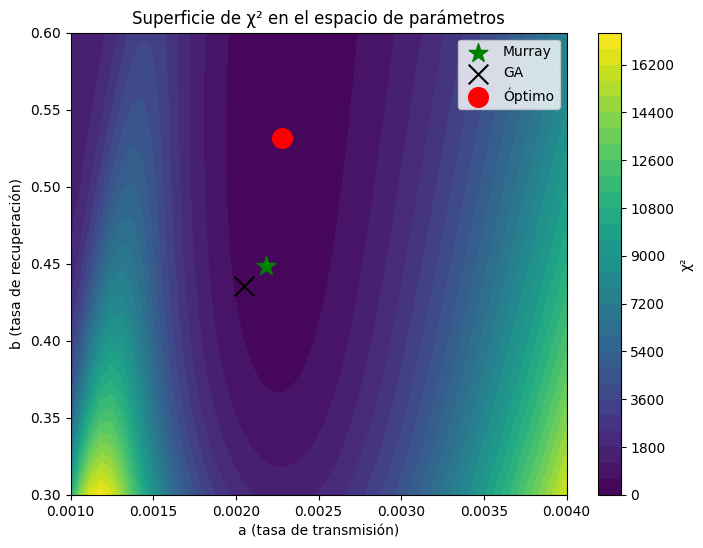

In [58]:
plt.figure(figsize=(8, 6))
contour = plt.contourf(A, B, Z, levels=30, cmap='viridis')
plt.colorbar(contour, label='χ²')
plt.scatter(a_murray, b_murray, color='green', marker='*', s=200, label='Murray')
plt.scatter(a_ga, b_ga, color='black', marker='x', s=200, label='GA')
plt.scatter(a_opt, b_opt, color='red', marker='o', s=200, label='Óptimo') # Añadido el punto óptimo
plt.xlabel('a (tasa de transmisión)')
plt.ylabel('b (tasa de recuperación)')
plt.title('Superficie de χ² en el espacio de parámetros')
plt.legend()
plt.show()

Algunas observaciones al respecto, se tienen:

* Superficie de $χ^2$, $(a,b)$ (chi cuadrada) (Paisaje de ajuste): La gráfica nos sigue mostrando cómo el valor de $χ^2$, $(a,b)$ (chi cuadrada) cambia con los parámetros a y b.
* Las regiones más oscuras (azules/púrpuras) indican valores bajos de $χ^2$, $(a,b)$ (chi cuadrada), es decir, un mejor ajuste del modelo a los datos, mientras que las regiones más claras (amarillas) indican un peor ajuste.
* Parámetros Óptimos (Círculo rojo): El círculo rojo que representa (a_opt, b_opt) está ubicado precisamente en la región más oscura y profunda de la gráfica. Esto es exactamente lo que esperábamos, ya que estos parámetros se encontraron a través de un proceso de minimización diseñado para hallar el mínimo global de la función $χ^2$, $(a,b)$ (chi cuadrada).
* Parámetros de Murray (Estrella verde): La estrella verde (a_murray, b_murray) se encuentra en una región con un $χ^2$, $(a,b)$ (chi cuadrada) bajo, pero claramente no está en el mínimo absoluto. Está ligeramente desplazada del 'valle' más profundo, lo que confirma que, aunque es un buen punto de partida, no es el ajuste óptimo.
* Parámetros del Algoritmo Genético (Cruz negra): La cruz negra (a_ga, b_ga) está en una región de $χ^2$, $(a,b)$ (chi cuadrada) mucho más alta (colores más claros), lo que visualmente reconfirma que el algoritmo genético, en su configuración actual, no logró encontrar un ajuste tan bueno como los otros métodos, ubicándose lejos del mínimo.


En resumen, la adición del punto óptimo nos permite ver visualmente la efectividad de la minimización, que logra posicionarse en el mejor ajuste posible dentro del espacio de parámetros explorado, superando tanto los parámetros de referencia de Murray como los resultados del Algoritmo Genético.



**4. Usar el método MCMC (Metropolis Hastings) para optimizar $χ^2$.**



In [77]:
#importamos librerias
import matplotlib.pyplot as plt
import scipy.stats as st
import matplotlib as mpl
import seaborn as sb
import pandas as pd
import numpy as np


from matplotlib import animation, rc
from IPython.display import HTML
%matplotlib inline
sb.set()

### Inicialización de la Cadena de Markov para Metropolis-Hastings

Aquí preparamos el algoritmo de Metropolis-Hastings para explorar el espacio de parámetros $(a, b)$ y muestrear la distribución posterior. Necesitamos:

1.  **Puntos de inicio:** Un conjunto de valores iniciales para $a$ y $b$.
2.  **Número de iteraciones:** Cuántos pasos dará la cadena.
3.  **Distribución propuesta:** Cómo propondremos nuevos valores de $a$ y $b$.
4.  **Almacenamiento:** Listas para guardar la historia de los parámetros y los valores de $χ^2$.

Usamos los parámetros óptimos encontrados por minimización de chi-cuadrado como punto de partida.

In [84]:
# --- 1. Puntos de inicio ---
current_a = a_opt
current_b = b_opt
current_chi2 = chi_squared_sir([current_a, current_b])


Un número suficientemente grande para que la cadena explore bien el espacio.

In [85]:
# --- 2. Número de iteraciones ---
n_iterations = 50000

 Definimos la desviación estándar para la distribución normal que propondrá nuevos pasos.

In [ ]:

# --- 3. Distribución propuesta ---

proposal_sd_a = 5e-6 # Una pequeña desviación para 'a'
proposal_sd_b = 5e-3 # Una pequeña desviación para 'b'

Listas para guardar la historia de la cadena de Markov

In [ ]:
# --- 4. Almacenamiento ---
chain_a = [current_a]
chain_b = [current_b]
chi2_history = [current_chi2]

Lo visualizamos

In [80]:

# Imprimimos el estado inicial
print(f"MCMC Inicializado:")
print(f"  a_inicial = {current_a:.6f}")
print(f"  b_inicial = {current_b:.6f}")
print(f"  chi2_inicial = {current_chi2:.4f}")
print(f"  Número de iteraciones: {n_iterations}")
print(f"  Desviación estándar propuesta para a: {proposal_sd_a}")
print(f"  Desviación estándar propuesta para b: {proposal_sd_b}")

MCMC Inicializado:
  a_inicial = 0.002277
  b_inicial = 0.531540
  chi2_inicial = 121.4984
  Número de iteraciones: 50000
  Desviación estándar propuesta para a: 5e-06
  Desviación estándar propuesta para b: 0.005


### Bucle Principal de Metropolis-Hastings

Ahora implementamos el bucle principal del algoritmo:

1.  **Proponer nuevos parámetros:** Generamos un nuevo candidato $(a_{propuesta}, b_{propuesta})$ a partir del estado actual usando una distribución de probabilidad (e.g., normal).
2.  **Calcular $χ^2$:** Evaluamos la función $χ^2$ para los parámetros propuestos.
3.  **Calcular probabilidad de aceptación:** Determinamos si aceptamos o rechazamos los nuevos parámetros basándonos en la relación de $χ^2$ (que está inversamente relacionada con la *likelihood*) y un prior uniforme (asegurando que los parámetros estén dentro de límites razonables).
4.  **Actualizar o mantener el estado:** Si aceptamos, el nuevo estado se convierte en el actual; de lo contrario, nos quedamos con el estado anterior.
5.  **Guardar:** Registramos los parámetros actuales en la historia de la cadena.

In [86]:
for i in range(n_iterations):
    # 1. Proponer nuevos parámetros (a_propuesto, b_propuesto)
    # Usamos una distribución normal centrada en el valor actual
    proposed_a = random.gauss(current_a, proposal_sd_a)
    proposed_b = random.gauss(current_b, proposal_sd_b)

    # Aplicar límites (bounds) para asegurar que los parámetros sean realistas
    # (ej. a y b deben ser positivos y dentro de un rango sensato)
    min_a, max_a = bounds[0]
    min_b, max_b = bounds[1]

    if not (min_a <= proposed_a <= max_a and min_b <= proposed_b <= max_b):
        # Si los parámetros propuestos están fuera de los límites, no los aceptamos
        # y simplemente mantenemos el estado actual.
        chain_a.append(current_a)
        chain_b.append(current_b)
        chi2_history.append(current_chi2)
        continue

    # 2. Calcular chi-cuadrado para los parámetros propuestos
    proposed_chi2 = chi_squared_sir([proposed_a, proposed_b])

    # 3. Calcular la probabilidad de aceptación (ratio de Metropolis-Hastings)
    # Usamos la relación e^(-1/2 * chi2_propuesto) / e^(-1/2 * chi2_actual)
    # que se simplifica a exp(-0.5 * (chi2_propuesto - chi2_actual))
    acceptance_ratio = np.exp(-0.5 * (proposed_chi2 - current_chi2))

    # Como estamos minimizando chi2, valores más pequeños de chi2
    # corresponden a mayores "likelihoods" y por lo tanto a mayor ratio de aceptación.

    # Generar un número aleatorio para decidir la aceptación
    u = random.random()

    # 4. Aceptar o rechazar los parámetros propuestos
    if u < acceptance_ratio:
        current_a = proposed_a
        current_b = proposed_b
        current_chi2 = proposed_chi2

    # 5. Guardar el estado actual en la cadena
    chain_a.append(current_a)
    chain_b.append(current_b)
    chi2_history.append(current_chi2)

print(f"MCMC completado. Se generaron {len(chain_a)} muestras.")

MCMC completado. Se generaron 100001 muestras.


### Análisis de los resultados de MCMC

Una vez que la cadena de Markov ha sido generada, necesitamos analizarla para obtener los parámetros óptimos y su incertidumbre.

1.  **Descartar Burn-in:** Eliminamos las primeras muestras, ya que corresponden al período de "calentamiento" del algoritmo.
2.  **Visualizar Trazas:** Graficamos la evolución de los parámetros a lo largo de las iteraciones para verificar la convergencia y mezcla de la cadena.
3.  **Histogramas y Estadísticas Posteriores:** Analizamos la distribución de los parámetros para obtener sus valores centrales y los intervalos de credibilidad.

In [87]:
# --- 1. Descartar Burn-in ---
burn_in = int(n_iterations * 0.2) # Descartar el primer 20% de las iteraciones

# Aplicar burn-in a las cadenas
chain_a_post_burnin = chain_a[burn_in:]
chain_b_post_burnin = chain_b[burn_in:]
chi2_history_post_burnin = chi2_history[burn_in:]

print(f"Se descartaron {burn_in} muestras como burn-in.")
print(f"Quedan {len(chain_a_post_burnin)} muestras para el análisis.")

Se descartaron 10000 muestras como burn-in.
Quedan 90001 muestras para el análisis.


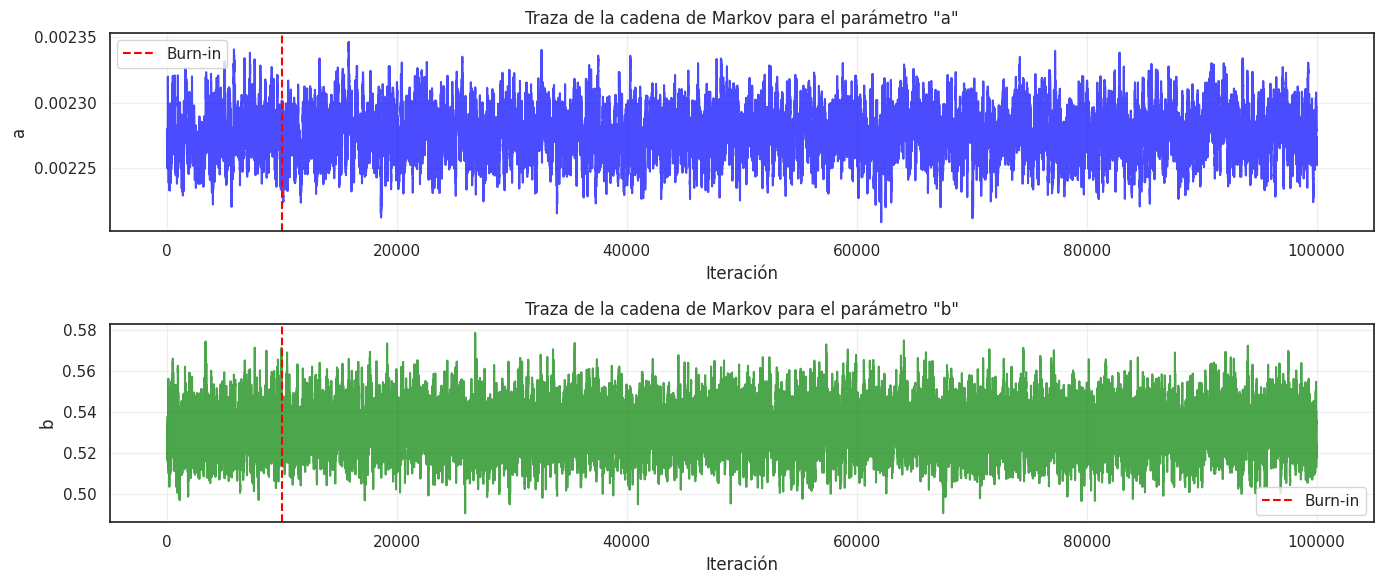

In [95]:
# --- 2. Visualizar Trazas de las Cadenas ---
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(chain_a, color='blue', alpha=0.7)
plt.title('Traza de la cadena de Markov para el parámetro "a"')
plt.ylabel('a')
plt.xlabel('Iteración')
plt.axvline(burn_in, color='red', linestyle='--', label='Burn-in')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(2, 1, 2)
plt.plot(chain_b, color='green', alpha=0.7)
plt.title('Traza de la cadena de Markov para el parámetro "b"')
plt.ylabel('b')
plt.xlabel('Iteración')
plt.axvline(burn_in, color='red', linestyle='--', label='Burn-in')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




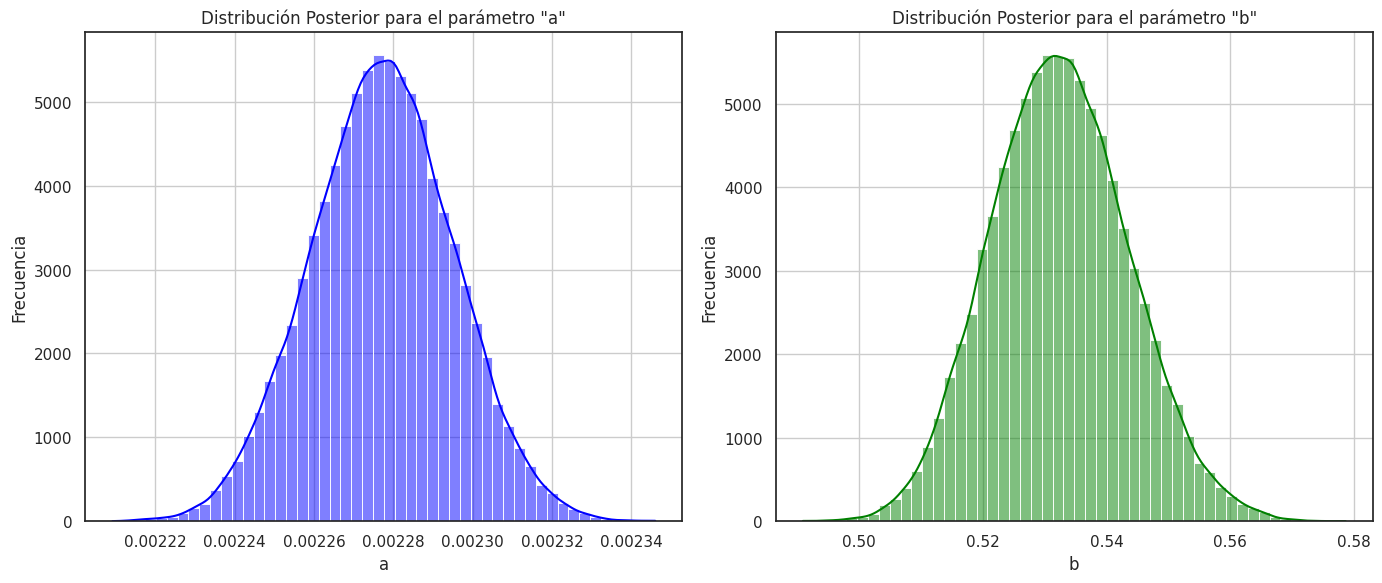

In [96]:

# --- 3. Histogramas y Estadísticas Posteriores ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(chain_a_post_burnin, kde=True, color='blue', bins=50)
plt.title('Distribución Posterior para el parámetro "a"')
plt.xlabel('a')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(chain_b_post_burnin, kde=True, color='green', bins=50)
plt.title('Distribución Posterior para el parámetro "b"')
plt.xlabel('b')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


Estadísticas descriptivas de las distribuciones posteriores

In [97]:

mean_a_mcmc = np.mean(chain_a_post_burnin)
median_a_mcmc = np.median(chain_a_post_burnin)
std_a_mcmc = np.std(chain_a_post_burnin)

mean_b_mcmc = np.mean(chain_b_post_burnin)
median_b_mcmc = np.median(chain_b_post_burnin)
std_b_mcmc = np.std(chain_b_post_burnin)

print("\n--- Estadísticas de los parámetros MCMC (post-burn-in) ---")
print(f"Parámetro 'a':")
print(f"  Media: {mean_a_mcmc:.6f}")
print(f"  Mediana: {median_a_mcmc:.6f}")
print(f"  Desviación Estándar: {std_a_mcmc:.6f}")

print(f"\nParámetro 'b':")
print(f"  Media: {mean_b_mcmc:.6f}")
print(f"  Mediana: {median_b_mcmc:.6f}")
print(f"  Desviación Estándar: {std_b_mcmc:.6f}")


--- Estadísticas de los parámetros MCMC (post-burn-in) ---
Parámetro 'a':
  Media: 0.002277
  Mediana: 0.002277
  Desviación Estándar: 0.000018

Parámetro 'b':
  Media: 0.532431
  Mediana: 0.532212
  Desviación Estándar: 0.011135


El mejor chi cuadrado encontrado por MCMC

In [98]:

best_chi2_mcmc = np.min(chi2_history_post_burnin)
print(f"\nMejor χ² encontrado por MCMC: {best_chi2_mcmc:.4f}")


Mejor χ² encontrado por MCMC: 121.4984


Los intervalos de creadibilidad del $95\%$

In [99]:
# Calcular los intervalos de credibilidad del 95%
lower_a, upper_a = np.percentile(chain_a_post_burnin, [2.5, 97.5])
lower_b, upper_b = np.percentile(chain_b_post_burnin, [2.5, 97.5])

print("\n--- Intervalos de Credibilidad del 95% (MCMC) ---")
print(f"a: [{lower_a:.6f}, {upper_a:.6f}]")
print(f"b: [{lower_b:.6f}, {upper_b:.6f}]")



--- Intervalos de Credibilidad del 95% (MCMC) ---
a: [0.002242, 0.002312]
b: [0.511453, 0.554888]


In [100]:
# Comparar soluciones
t_sol_mcmc, _, I_sol_mcmc, _ = solve_sir(a_mean, b_mean)

plt.figure(figsize=(10, 6))
plt.scatter(t_datos, I_datos, color='red', s=80, label='Datos', zorder=5)
plt.plot(t_sol, I_sol, 'b--', label=f'Murray (a={a_murray}, b={b_murray})')
plt.plot(t_sol_mcmc, I_sol_mcmc, 'g-', linewidth=2,
         label=f'MCMC (a={a_mean:.5f}, b={b_mean:.5f})')
plt.xlabel('Tiempo t (días)')
plt.ylabel('Infectados I(t)')
plt.title('Comparación de ajustes: Murray vs MCMC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'solve_sir' is not defined

# Estimación de párametros del modelo SIR usando un AG

In [59]:
# ============================================================
# INSTALACIÓN DE DEAP
# ============================================================

!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 17.9 MB/s eta 0:00:00


In [60]:
# Librerías para resolver numéricamente el sistema de ecuaciones
from scipy.integrate import odeint
from scipy.interpolate import interp1d

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para el algoritmo genético
from deap import base, creator, tools

import random



### Optimización con el algoritmo genético

In [61]:
# problem constants:
DIMENSIONS = 2  # number of dimensions
BOUND_LOW, BOUND_UP = 0.0, 1.0  # boundaries for all dimensions

In [62]:
# Genetic Algorithm constants:
POPULATION_SIZE = 100
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.45  # (try also 0.5) probability for mutating an individual
MAX_GENERATIONS = 500
HALL_OF_FAME_SIZE = 1
CROWDING_FACTOR = 1.0  # crowding factor for crossover and mutation

# set the random seed:
#RANDOM_SEED = 42
#random.seed(RANDOM_SEED)

In [63]:
toolbox = base.Toolbox()

In [64]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

In [65]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

In [66]:
# helper function for creating random real numbers uniformly distributed within a given range [low, up]
# it assumes that the range is the same for every dimension
def randomFloat(low, up):
    return [random.uniform(l, u) for l, u in zip([low] * DIMENSIONS, [up] * DIMENSIONS)]

In [67]:
# create an operator that randomly returns a float in the desired range and dimension:
toolbox.register("attrFloat", randomFloat, BOUND_LOW, BOUND_UP)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.attrFloat)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)

In [68]:
# Sistema de ecuaciones del modelo SIR.
def deriv(Y, t, N, a, b):
    S, I, R = Y
    dSdt = -a * S * I
    dIdt = a * S * I - b * I
    dRdt = b * I
    return dSdt, dIdt, dRdt

In [69]:
# Esta funcion calcula la distancia Manhattan entre los datos numericos y los reales.

def manhattan(individual):
    x = individual[0]
    y = individual[1]

    N = 763

    I0, R0 = 1, 0
    S0 = N - I0 - R0
    t = np.linspace(0, 15, 15)

    y0 = S0, I0, R0

    ret = odeint(deriv, y0, t, args=(N, x, y))
    S, I, R = ret.T


#    delta = np.absolute(ret.T[1] - datos_school)
#    f = np.sum(delta)

    delta = (np.absolute(ret.T[1] - datos_school)**2)/ret.T[1]
    f = np.sum(delta)

    return f,

In [70]:
datos_school = [1, 3, 6, 25, 73, 222, 294, 258, 237, 191, 125, 69, 27, 11, 4 ]

In [71]:
toolbox.register("evaluate", manhattan)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR,
                 indpb=1.0/DIMENSIONS)

In [72]:
%%writefile elitism.py

import random
from deap import tools


def eaSimpleWithElitism(population, toolbox, cxpb, mutpb, ngen,
                        stats=None, halloffame=None, verbose=True):

    logbook = tools.Logbook()
    logbook.header = ["gen", "nevals"]

    if stats is not None:
        logbook.header += stats.fields

    # Evaluar individuos de la población inicial
    invalid_ind = [
        ind for ind in population
        if not ind.fitness.valid
    ]

    fitnesses = map(toolbox.evaluate, invalid_ind)

    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Actualizar Hall of Fame
    if halloffame is not None:
        halloffame.update(population)

    # Registrar estadísticas iniciales
    record = stats.compile(population) if stats else {}

    logbook.record(
        gen=0,
        nevals=len(invalid_ind),
        **record
    )

    if verbose:
        print(logbook.stream)


    # CICLO PRINCIPAL DEL ALGORITMO GENÉTICO


    for gen in range(1, ngen + 1):


        # ELITISMO

        # Guardamos el mejor individuo de la generación anterior

        elite = tools.selBest(
            population,
            1
        )[0]

        elite = toolbox.clone(elite)


        # SELECCIÓN


        offspring = toolbox.select(
            population,
            len(population) - 1
        )

        offspring = list(
            map(toolbox.clone, offspring)
        )

        # CRUZAMIENTO


        for child1, child2 in zip(
            offspring[::2],
            offspring[1::2]
        ):

            if random.random() < cxpb:

                toolbox.mate(
                    child1,
                    child2
                )

                del child1.fitness.values
                del child2.fitness.values

        # MUTACIÓN


        for mutant in offspring:

            if random.random() < mutpb:

                toolbox.mutate(mutant)

                del mutant.fitness.values


        # EVALUACIÓN

        invalid_ind = [
            ind for ind in offspring
            if not ind.fitness.valid
        ]

        fitnesses = map(
            toolbox.evaluate,
            invalid_ind
        )

        for ind, fit in zip(
            invalid_ind,
            fitnesses
        ):

            ind.fitness.values = fit


        # ACTUALIZAR HALL OF FAME


        if halloffame is not None:
            halloffame.update(offspring)


        # NUEVA POBLACIÓN

        # El mejor individuo pasa directamente a la siguiente
        # generación sin cruzamiento ni mutación.

        population[:] = [elite] + offspring


        # ESTADÍSTICAS


        record = stats.compile(population) if stats else {}

        logbook.record(
            gen=gen,
            nevals=len(invalid_ind),
            **record
        )

        if verbose:
            print(logbook.stream)

    return population, logbook

Writing elitism.py


In [73]:
import elitism

print("Módulo elitism cargado correctamente.")

Módulo elitism cargado correctamente.


gen	nevals	min    	avg   
0  	100   	1953.82	341930
1  	96    	1944.35	81599.9
2  	93    	1944.14	29846.6
3  	93    	1942.61	5940.94
4  	97    	1942.61	32242.3
5  	97    	1942.46	13330.6
6  	90    	1942.46	29885.9
7  	88    	1941.57	21957.6
8  	90    	1941.37	7122.58
9  	93    	1941.05	12674.6
10 	97    	1941.03	32281.1
11 	97    	1941.03	45327.1
12 	98    	1941.03	6305.89
13 	95    	1941.03	11247.1
14 	90    	1941.03	32183  
15 	95    	1941.03	20795.1
16 	95    	1941.02	32671.7
17 	93    	1941.02	22098.4
18 	97    	1941.02	26212  
19 	94    	1941.01	39773.5
20 	96    	1941.01	55231.5
21 	95    	1941.01	29428  
22 	94    	1941.01	48600.8
23 	88    	1941.01	7235.2 
24 	91    	1941.01	62484  
25 	97    	1941.01	14457.6
26 	94    	1941.01	9787.57
27 	93    	1941.01	21743.8
28 	92    	1941.01	47815  
29 	92    	1941.01	31342.1
30 	90    	1941.01	43789.7
31 	88    	1941.01	21744.5
32 	93    	1941.01	11416  
33 	93    	1941.01	10502.9
34 	93    	1941.01	17268.4
35 	94    	1941.01	7962.28
36 

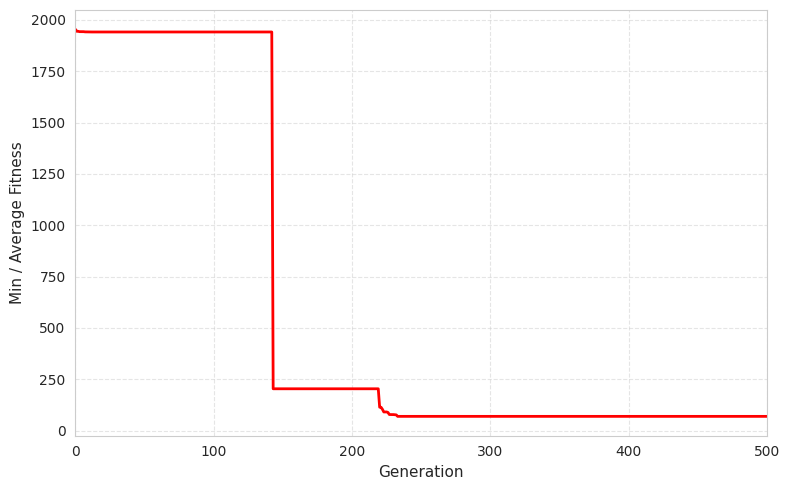

In [74]:

# Genetic Algorithm flow:

def main():


    # CREAR POBLACIÓN INICIAL


    population = toolbox.populationCreator(
        n=POPULATION_SIZE
    )


    # ESTADÍSTICAS


    stats = tools.Statistics(
        lambda ind: ind.fitness.values
    )

    stats.register(
        "min",
        np.min
    )

    stats.register(
        "avg",
        np.mean
    )


    # HALL OF FAME


    hof = tools.HallOfFame(
        HALL_OF_FAME_SIZE
    )


    # ALGORITMO GENÉTICO CON ELITISMO


    population, logbook = elitism.eaSimpleWithElitism(
        population,
        toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=True
    )


    # MEJOR SOLUCIÓN ENCONTRADA


    best = hof.items[0]

    print("\n-- Best Individual = ", best)

    print(
        "-- Best Fitness = ",
        best.fitness.values[0]
    )

    # EXTRAER ESTADÍSTICAS


    minFitnessValues, meanFitnessValues = logbook.select(
        "min",
        "avg"
    )



    # GRÁFICA

    sns.set_style("whitegrid")

    plt.figure(figsize=(8, 5))

    plt.plot(
        minFitnessValues,
        color='red',
        linewidth=2
    )

    plt.xlabel(
        'Generation',
        fontsize=11
    )

    plt.ylabel(
        'Min / Average Fitness',
        fontsize=11
    )

    plt.xlim(
        0,
        MAX_GENERATIONS
    )

    plt.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        'GA_Evolution_1.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()



# EJECUTAR

if __name__ == "__main__":
    main()

In [75]:
def funcion_objetivo(x_0, x_1):

    N = 763
    I0, R0 = 1, 0
    S0 = N - I0 - R0
    t = np.linspace(0, 15, 15)

    y0 = S0, I0, R0


    def deriv(y, t, N, beta, gamma):
        S, I, R = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return dSdt, dIdt, dRdt

    ret = odeint(deriv, y0, t, args=(N, x_0, x_1))
    S, I, R = ret.T


#    datos = ret.T[1]
#    print(ret.T[1])

    fig = plt.figure(facecolor='w')
    ax = fig.add_subplot(111, axisbelow='line')
    ax.plot(datos_school, 'ro', alpha=0.5, lw=2, label='Data')
#    ax.plot(t, ret.T[1], 'b', alpha=0.5, lw=2, label='Best fitness')
    f2 = interp1d(t, ret.T[1], kind='cubic')
    t = np.linspace(0, 15, num=101)
    ax.plot(t, f2(t), 'b', alpha=0.5, lw=2, label='Best fit')
    ax.set_xlabel('t', fontsize=15)
    ax.set_ylabel('I(t)', fontsize=15)
    #ax.set_title("GA's approximation", fontsize=15)
    ax.legend()
    plt.grid(visible = False)
    fig.savefig('best_fit.png')
    plt.show()

    delta = np.absolute(ret.T[1] - datos_school)
    manhattan = np.sum(delta)
    f = manhattan

    return(f)

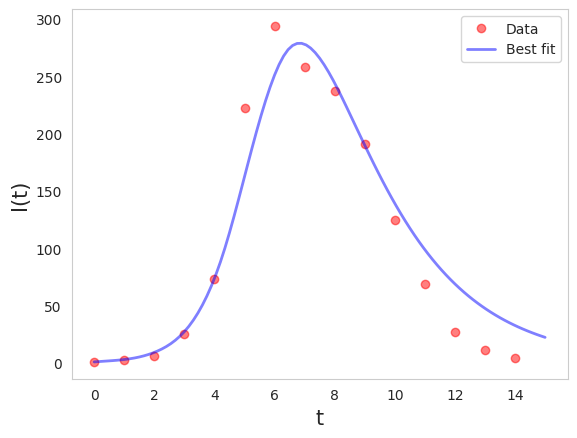

np.float64(233.91513917335863)

In [76]:
#funcion_objetivo(0.00218, 0.4436)
funcion_objetivo(0.002047488430022274, 0.4355147691971053)

## <span style="color:magenta">**Conclusión:**</span>

Todos los métodos coinciden en que $R_0 = a/b \approx 4.7\text{–}4.9$, lo que indica que **la epidemia fue relativamente contagiosa** (cada infectado contagia a ~5 personas en promedio). Esta **consistencia entre métodos** es la validación más fuerte de que el modelo SIR captura la dinámica esencial del brote, independientemente del método de ajuste usado.